# GPS-Less Localization — Model Training


## 0. Configuration

In [2]:
# ── PATHS ──────────────────────────────────────────────────────────────────────
FINGERPRINTS_CSV  = "fingerprints.csv"   # Input fingerprint dataset
OUTPUT_DIR        = "."                       # Where to save model artifacts

# ── PRUNING HYPERPARAMETERS ────────────────────────────────────────────────────
THRESHOLDS   = [12, 15, 18, 20, 22, 25, 30]  # LOO error thresholds to try (metres)
K_VALUES     = [2, 3, 4]                      # KNN k values to try during grid search
MAX_ITER     = 8                              # Max pruning iterations
MIN_POINTS   = 80                             # Don't prune below this many points

# ── CROSS-VALIDATION ──────────────────────────────────────────────────────────
CV_SPLITS    = 5
CV_REPEATS_FAST   = 3    # Used during grid search (speed)
CV_REPEATS_FINAL  = 10   # Used for final evaluation (accuracy)

# ── RADIO / FEATURE CONSTANTS ─────────────────────────────────────────────────
VALID_ANCHORS      = ['A1', 'A2', 'A3', 'A4', 'A5']
RSSI_FLOOR         = -120.0
SNR_FLOOR          = -20.0
EXPECTED_LORA_COUNT = 30

## 1. Imports & Helpers

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib, os, warnings
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.model_selection import RepeatedKFold

warnings.filterwarnings('ignore')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("All imports OK.")


# ── Haversine distance in metres ───────────────────────────────────────────────
def haversine_m(la1, lo1, la2, lo2):
    R = 6_371_000.0
    a = (np.sin(np.radians((la2 - la1) / 2)) ** 2 +
         np.cos(np.radians(la1)) * np.cos(np.radians(la2)) *
         np.sin(np.radians((lo2 - lo1) / 2)) ** 2)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


# ── LOO-CV using NearestNeighbors (fast, vectorised) ──────────────────────────
def compute_loo_errors(df, feat_cols, label_cols, k=3):
    """
    For every point i, predict its location using k nearest neighbours
    (excluding itself). Returns array of per-point Haversine errors in metres.
    """
    X  = df[feat_cols].values
    y  = df[label_cols].values
    sc = StandardScaler()
    Xs = sc.fit_transform(X)

    nn = NearestNeighbors(n_neighbors=k + 1)   # +1: point i is its own neighbour
    nn.fit(Xs)
    dists, idxs = nn.kneighbors(Xs)

    errors = []
    for i in range(len(Xs)):
        ni = idxs[i, 1 : k + 1]               # skip self at position 0
        nd = dists[i, 1 : k + 1]
        w  = 1.0 / np.maximum(nd, 1e-9)
        w /= w.sum()
        pred = (w[:, None] * y[ni]).sum(axis=0)
        errors.append(float(haversine_m(y[i, 0], y[i, 1], pred[0], pred[1])))

    return np.array(errors)


# ── Repeated K-Fold CV ─────────────────────────────────────────────────────────
def cv_evaluate(df, feat_cols, label_cols, k, n_splits=5, n_repeats=3):
    """
    Returns array of per-sample Haversine errors from repeated K-Fold CV.
    """
    X = df[feat_cols].values
    y = df[label_cols].values
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)
    all_errors = []

    for train_idx, val_idx in rkf.split(X):
        sc  = StandardScaler()
        Xtr = sc.fit_transform(X[train_idx])
        Xva = sc.transform(X[val_idx])

        model = KNeighborsRegressor(n_neighbors=k, weights='distance')
        model.fit(Xtr, y[train_idx])
        preds = model.predict(Xva)

        for true, pred in zip(y[val_idx], preds):
            all_errors.append(haversine_m(true[0], true[1], pred[0], pred[1]))

    return np.array(all_errors)


print("Helper functions defined.")

All imports OK.
Helper functions defined.


## 2. Load Dataset

In [4]:
df_orig    = pd.read_csv(FINGERPRINTS_CSV)
label_cols = ['latitude', 'longitude']
feat_cols  = [c for c in df_orig.columns if c not in label_cols]

print(f"Loaded: {df_orig.shape[0]} locations  |  {len(feat_cols)} features")
print(f"Feature columns: {feat_cols[:5]} ... ({len(feat_cols)} total)")
print()
print("Label summary:")
print(df_orig[label_cols].describe().round(6))

Loaded: 442 locations  |  100 features
Feature columns: ['DIFF_BLE_A1_A5', 'DIFF_BLE_A1_A3', 'A5_BLE_max', 'A5_WIFI_max', 'A3_BLE_max'] ... (100 total)

Label summary:
         latitude   longitude
count  442.000000  442.000000
mean    12.842596   80.153552
std      0.000439    0.000426
min     12.841670   80.152550
25%     12.842220   80.153240
50%     12.842600   80.153535
75%     12.842978   80.153880
max     12.843460   80.154370


## 3. Baseline Evaluation

In [5]:
print("Running baseline CV (all points, k=3) — this may take ~30 seconds...")
e_base = cv_evaluate(df_orig, feat_cols, label_cols,
                     k=3, n_splits=CV_SPLITS, n_repeats=CV_REPEATS_FAST)

print(f"\nBaseline ({len(df_orig)} pts, k=3, {CV_SPLITS}-fold × {CV_REPEATS_FAST} repeats):")
print(f"  MAE    = {e_base.mean():.2f} m")
print(f"  Median = {np.median(e_base):.2f} m")
print(f"  P75    = {np.percentile(e_base, 75):.2f} m")
print(f"  P90    = {np.percentile(e_base, 90):.2f} m")
print(f"  Max    = {e_base.max():.2f} m")

Running baseline CV (all points, k=3) — this may take ~30 seconds...

Baseline (442 pts, k=3, 5-fold × 3 repeats):
  MAE    = 22.67 m
  Median = 16.21 m
  P75    = 28.81 m
  P90    = 46.82 m
  Max    = 188.57 m


## 4. Initial LOO Error Distribution

Computing LOO errors on all points...
LOO error summary:
  Mean   = 22.32 m
  Median = 16.06 m
  P90    = 43.36 m
  Max    = 176.13 m

  LOO >  15m: 238 pts (53.8%)
  LOO >  18m: 202 pts (45.7%)
  LOO >  20m: 172 pts (38.9%)
  LOO >  25m: 129 pts (29.2%)
  LOO >  30m:  96 pts (21.7%)
  LOO >  40m:  50 pts (11.3%)
  LOO >  50m:  36 pts (8.1%)
  LOO >  75m:  13 pts (2.9%)


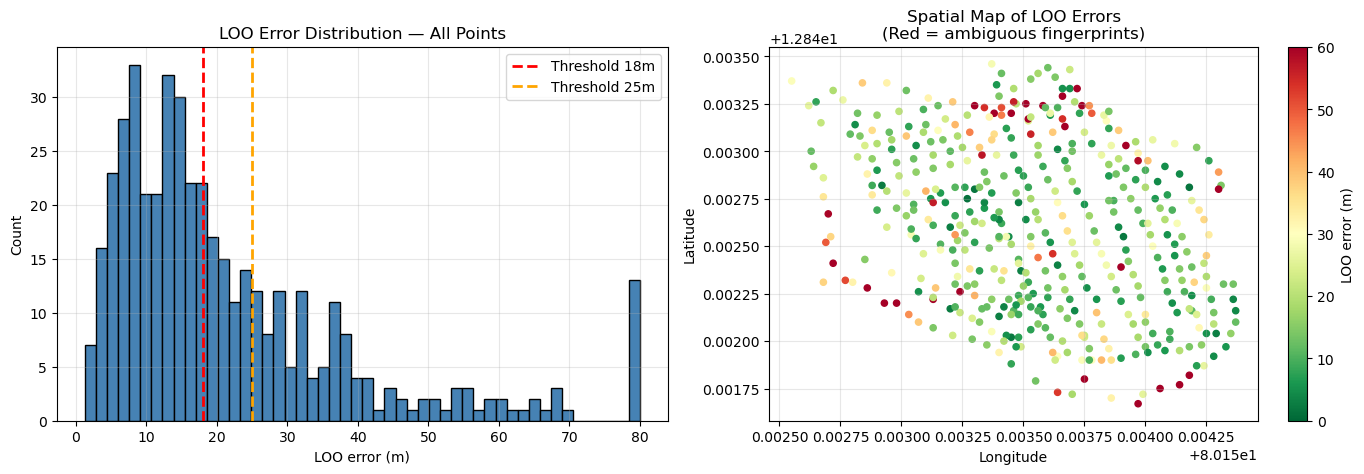

In [6]:
print("Computing LOO errors on all points...")
loo_init = compute_loo_errors(df_orig, feat_cols, label_cols, k=3)

print(f"LOO error summary:")
print(f"  Mean   = {loo_init.mean():.2f} m")
print(f"  Median = {np.median(loo_init):.2f} m")
print(f"  P90    = {np.percentile(loo_init, 90):.2f} m")
print(f"  Max    = {loo_init.max():.2f} m")
print()
for t in [15, 18, 20, 25, 30, 40, 50, 75]:
    n = (loo_init > t).sum()
    print(f"  LOO > {t:3d}m: {n:3d} pts ({100*n/len(loo_init):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(loo_init.clip(0, 80), bins=50, edgecolor='black', color='steelblue')
for t, col, lbl in [(18, 'red', '18m'), (25, 'orange', '25m')]:
    axes[0].axvline(t, color=col, linestyle='--', linewidth=2, label=f'Threshold {lbl}')
axes[0].set_title('LOO Error Distribution — All Points')
axes[0].set_xlabel('LOO error (m)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(df_orig['longitude'], df_orig['latitude'],
                     c=loo_init.clip(0, 60), cmap='RdYlGn_r',
                     vmin=0, vmax=60, s=20)
plt.colorbar(sc, ax=axes[1], label='LOO error (m)')
axes[1].set_title('Spatial Map of LOO Errors\n(Red = ambiguous fingerprints)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loo_initial_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Iterative LOO Pruning

**Algorithm:**
1. Compute LOO error for every point in the current dataset
2. Grid-search over thresholds T and k: evaluate CV MAE after removing points with LOO > T
3. Apply the best threshold — permanently remove those points
4. Repeat until the dataset size stops changing (convergence)

In [7]:
df_cur      = df_orig.copy()
history     = []
best_global = {'mae': 999, 'df': None, 'k': 3, 'iteration': 0, 'thresh': None}
prev_n      = len(df_cur)

print(f"Starting pruning: {len(df_cur)} points")
print(f"{'Iter':>5}  {'Threshold':>10}  {'k':>3}  {'N kept':>7}  {'Removed':>8}  "
      f"{'CV MAE':>8}  {'Median':>8}  {'P90':>8}")
print("-" * 72)

for iteration in range(1, MAX_ITER + 1):

    # Step 1: LOO on current dataset
    loo_e = compute_loo_errors(df_cur, feat_cols, label_cols, k=3)

    # Step 2: Grid search
    iter_best = {'mae': 999}
    for thresh in THRESHOLDS:
        keep_mask = loo_e <= thresh
        if keep_mask.sum() < MIN_POINTS:
            continue
        df_cand = df_cur.iloc[keep_mask].reset_index(drop=True)
        for k in K_VALUES:
            e = cv_evaluate(df_cand, feat_cols, label_cols,
                            k=k, n_splits=CV_SPLITS, n_repeats=CV_REPEATS_FAST)
            if e.mean() < iter_best['mae']:
                iter_best = {
                    'mae':    e.mean(),
                    'median': np.median(e),
                    'p90':    np.percentile(e, 90),
                    'thresh': thresh,
                    'k':      k,
                    'n':      int(keep_mask.sum()),
                    'df':     df_cand,
                    'loo_e':  loo_e,
                }

    if iter_best['mae'] == 999:
        print("No valid candidate found — stopping.")
        break

    b = iter_best
    removed = prev_n - b['n']
    print(f"{iteration:5d}  {b['thresh']:>9d}m  {b['k']:3d}  {b['n']:7d}  "
          f"{removed:>7d}  {b['mae']:8.2f}m  {b['median']:8.2f}m  {b['p90']:8.2f}m")

    history.append({
        'iteration': iteration,
        'n_points':  b['n'],
        'cv_mae':    b['mae'],
        'cv_median': b['median'],
        'cv_p90':    b['p90'],
        'threshold': b['thresh'],
        'k':         b['k'],
        'loo_errors': b['loo_e'],
    })

    if b['mae'] < best_global['mae']:
        best_global.update({
            'mae':       b['mae'],
            'median':    b['median'],
            'p90':       b['p90'],
            'df':        b['df'],
            'k':         b['k'],
            'iteration': iteration,
            'thresh':    b['thresh'],
        })

    # Convergence check
    if b['n'] == prev_n:
        print(f"Converged at iteration {iteration} — dataset size unchanged.")
        break

    df_cur = b['df'].copy()
    prev_n = b['n']

print(f"\nBest result: Iter {best_global['iteration']}, k={best_global['k']}, "
      f"{len(best_global['df'])} pts, MAE={best_global['mae']:.2f}m")

Starting pruning: 442 points
 Iter   Threshold    k   N kept   Removed    CV MAE    Median       P90
------------------------------------------------------------------------
    1         18m    2      240      202     12.89m     10.95m     23.01m
    2         15m    2      171       69     10.84m      9.77m     18.79m
    3         25m    2      163        8      9.93m      9.38m     17.99m
    4         25m    2      162        1      9.75m      9.47m     16.92m
    5         25m    2      162        0      9.75m      9.47m     16.92m
Converged at iteration 5 — dataset size unchanged.

Best result: Iter 4, k=2, 162 pts, MAE=9.75m


## 6. Pruning Progress Plots

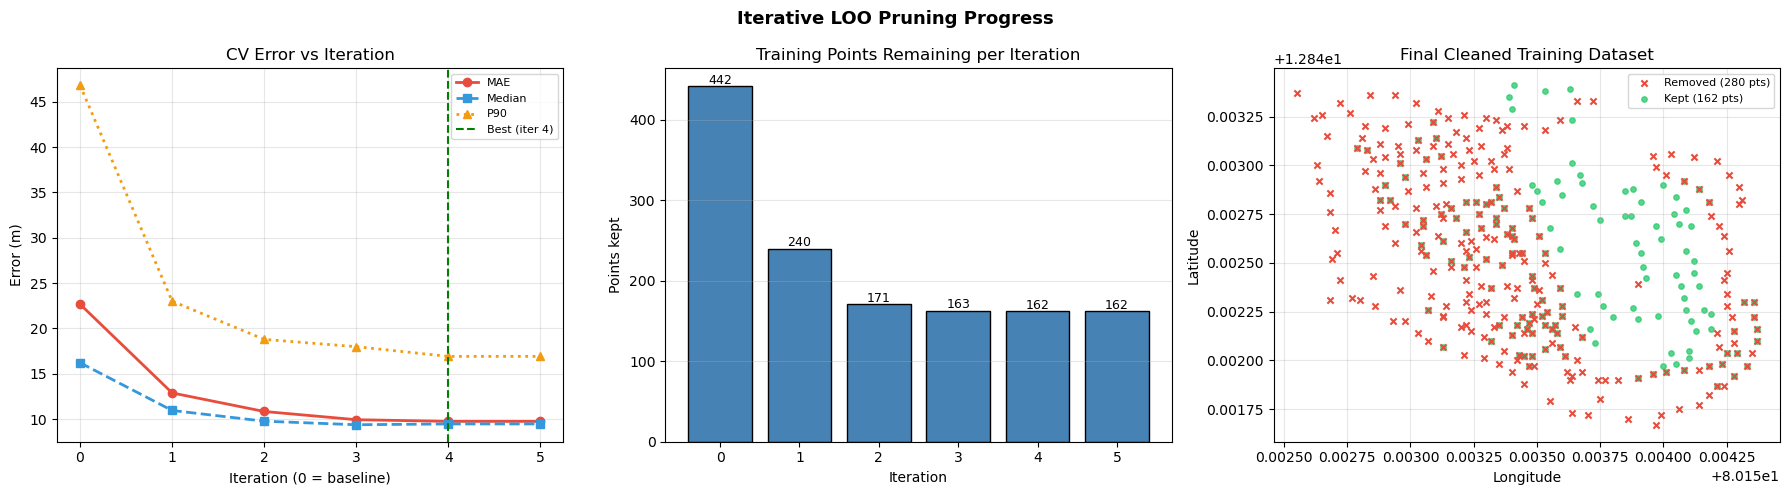

In [8]:
hist_df = pd.DataFrame(
    [{'iteration': 0, 'n_points': len(df_orig),
      'cv_mae': e_base.mean(), 'cv_median': np.median(e_base),
      'cv_p90': np.percentile(e_base, 90)}] +
    [{'iteration': h['iteration'], 'n_points': h['n_points'],
      'cv_mae': h['cv_mae'], 'cv_median': h['cv_median'],
      'cv_p90': h['cv_p90']} for h in history]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Iterative LOO Pruning Progress', fontsize=13, fontweight='bold')

# Error progression
axes[0].plot(hist_df['iteration'], hist_df['cv_mae'],    'o-',  color='#e74c3c', lw=2, label='MAE')
axes[0].plot(hist_df['iteration'], hist_df['cv_median'], 's--', color='#3498db', lw=2, label='Median')
axes[0].plot(hist_df['iteration'], hist_df['cv_p90'],    '^:',  color='#f39c12', lw=2, label='P90')
axes[0].axvline(best_global['iteration'], color='green', linestyle='--', lw=1.5,
                label=f"Best (iter {best_global['iteration']})")
axes[0].set_title('CV Error vs Iteration')
axes[0].set_xlabel('Iteration (0 = baseline)')
axes[0].set_ylabel('Error (m)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Points remaining
axes[1].bar(hist_df['iteration'], hist_df['n_points'], color='steelblue', edgecolor='black')
for _, row in hist_df.iterrows():
    axes[1].text(row['iteration'], row['n_points'] + 3, str(int(row['n_points'])),
                 ha='center', fontsize=9)
axes[1].set_title('Training Points Remaining per Iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Points kept')
axes[1].grid(alpha=0.3, axis='y')

# Spatial kept vs removed
kept_idx    = best_global['df'].index if best_global['df'] is not None else df_orig.index
removed_idx = df_orig.index.difference(kept_idx)
axes[2].scatter(df_orig.loc[removed_idx, 'longitude'], df_orig.loc[removed_idx, 'latitude'],
                c='#e74c3c', s=20, marker='x', label=f'Removed ({len(removed_idx)} pts)', zorder=3)
axes[2].scatter(best_global['df']['longitude'], best_global['df']['latitude'],
                c='#2ecc71', s=15, alpha=0.8, label=f"Kept ({len(best_global['df'])} pts)")
axes[2].set_title('Final Cleaned Training Dataset')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pruning_progress.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Model Evaluation (High-Confidence CV)

Running high-confidence CV on final dataset (162 pts, k=2, 5-fold × 10 repeats)...

  FINAL MODEL RESULTS
  Training points : 162 (from 442 original)
  KNN k           : 2
  MAE             : 9.82 m
  Median error    : 9.48 m
  P75             : 13.07 m
  P90             : 17.47 m
  Max             : 41.90 m
  Within 10m      : 54.8%
  Within 15m      : 83.8%
  Baseline MAE    : 22.67 m
  Improvement     : 12.85 m


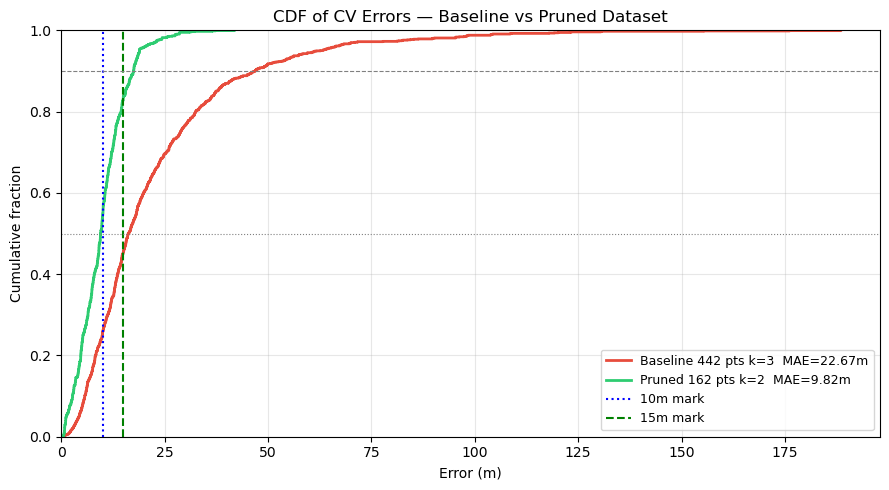

In [9]:
df_final = best_global['df']
k_final  = best_global['k']

print(f"Running high-confidence CV on final dataset "
      f"({len(df_final)} pts, k={k_final}, "
      f"{CV_SPLITS}-fold × {CV_REPEATS_FINAL} repeats)...")

e_final = cv_evaluate(df_final, feat_cols, label_cols,
                      k=k_final, n_splits=CV_SPLITS, n_repeats=CV_REPEATS_FINAL)

print(f"\n{'=' * 50}")
print(f"  FINAL MODEL RESULTS")
print(f"{'=' * 50}")
print(f"  Training points : {len(df_final)} (from {len(df_orig)} original)")
print(f"  KNN k           : {k_final}")
print(f"  MAE             : {e_final.mean():.2f} m")
print(f"  Median error    : {np.median(e_final):.2f} m")
print(f"  P75             : {np.percentile(e_final, 75):.2f} m")
print(f"  P90             : {np.percentile(e_final, 90):.2f} m")
print(f"  Max             : {e_final.max():.2f} m")
print(f"  Within 10m      : {(e_final <= 10).mean() * 100:.1f}%")
print(f"  Within 15m      : {(e_final <= 15).mean() * 100:.1f}%")
print(f"  Baseline MAE    : {e_base.mean():.2f} m")
print(f"  Improvement     : {e_base.mean() - e_final.mean():.2f} m")
print(f"{'=' * 50}")

# CDF plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.ecdf(e_base,  label=f'Baseline {len(df_orig)} pts k=3  MAE={e_base.mean():.2f}m',
        color='#e74c3c', linewidth=2)
ax.ecdf(e_final, label=f'Pruned {len(df_final)} pts k={k_final}  MAE={e_final.mean():.2f}m',
        color='#2ecc71', linewidth=2)
ax.axvline(10, color='blue',  linestyle=':', linewidth=1.5, label='10m mark')
ax.axvline(15, color='green', linestyle='--', linewidth=1.5, label='15m mark')
ax.axhline(0.50, color='gray', linestyle=':', linewidth=0.8)
ax.axhline(0.90, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('CDF of CV Errors — Baseline vs Pruned Dataset')
ax.set_xlabel('Error (m)')
ax.set_ylabel('Cumulative fraction')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, None)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'final_cdf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Model & Artifacts

In [10]:
# ── Train final model on ALL cleaned points ────────────────────────────────────
X_clean  = df_final[feat_cols].values
y_clean  = df_final[label_cols].values

sc_final = StandardScaler()
Xs_clean = sc_final.fit_transform(X_clean)

model_final = KNeighborsRegressor(n_neighbors=k_final, weights='distance')
model_final.fit(Xs_clean, y_clean)

# ── Save artifacts ─────────────────────────────────────────────────────────────
paths = {
    'model':    os.path.join(OUTPUT_DIR, 'final_model.pkl'),
    'scaler':   os.path.join(OUTPUT_DIR, 'final_scaler.pkl'),
    'features': os.path.join(OUTPUT_DIR, 'feature_columns.csv'),
    'cleaned':  os.path.join(OUTPUT_DIR, 'fingerprints_cleaned.csv'),
    'config':   os.path.join(OUTPUT_DIR, 'model_config.json'),
}

joblib.dump(model_final, paths['model'])
joblib.dump(sc_final,    paths['scaler'])
pd.Series(feat_cols).to_csv(paths['features'], index=False, header=['feature'])
df_final.to_csv(paths['cleaned'], index=False)

config = {
    'knn_k':              int(k_final),
    'n_training_points':  int(len(df_final)),
    'n_original_points':  int(len(df_orig)),
    'n_removed':          int(len(df_orig) - len(df_final)),
    'cv_mae_m':           round(float(e_final.mean()), 3),
    'cv_median_m':        round(float(np.median(e_final)), 3),
    'cv_p90_m':           round(float(np.percentile(e_final, 90)), 3),
    'pruning_iterations': int(best_global['iteration']),
    'final_threshold_m':  int(best_global['thresh']),
    'n_features':         int(len(feat_cols)),
    'valid_anchors':      VALID_ANCHORS,
    'rssi_floor':         RSSI_FLOOR,
    'snr_floor':          SNR_FLOOR,
    'expected_lora_count': EXPECTED_LORA_COUNT,
}
with open(paths['config'], 'w') as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
for name, path in paths.items():
    size = os.path.getsize(path)
    print(f"  {os.path.basename(path):<35}  ({size:,} bytes)")

print()
print(json.dumps(config, indent=2))

Saved artifacts:
  final_model.pkl                      (132,851 bytes)
  final_scaler.pkl                     (3,015 bytes)
  feature_columns.csv                  (1,428 bytes)
  fingerprints_cleaned.csv             (147,454 bytes)
  model_config.json                    (405 bytes)

{
  "knn_k": 2,
  "n_training_points": 162,
  "n_original_points": 442,
  "n_removed": 280,
  "cv_mae_m": 9.822,
  "cv_median_m": 9.482,
  "cv_p90_m": 17.474,
  "pruning_iterations": 4,
  "final_threshold_m": 25,
  "n_features": 100,
  "valid_anchors": [
    "A1",
    "A2",
    "A3",
    "A4",
    "A5"
  ],
  "rssi_floor": -120.0,
  "snr_floor": -20.0,
  "expected_lora_count": 30
}
